# VTA Ridership — ML Classification: Predict Route Crowding Level

**Task:** Predict whether a route-time combination will experience **Low**, **Medium**, or **High** crowding.

**Target:** `PEAK_LOAD` binned into 3 classes using 33rd/67th percentiles

**Models:** Logistic Regression → KNN → Random Forest → XGBoost

**7 Visualizations:** Confusion Matrix, ROC Curves, Feature Importance, SHAP, LDA Scatter, t-SNE Scatter, Model Comparison

---

In [1]:
!pip install pandas openpyxl numpy scikit-learn xgboost shap matplotlib seaborn

import pandas as pd
import numpy as np
import time
import datetime
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='colorblind')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import shap

print('All imports loaded successfully.')

All imports loaded successfully.


## Step 1: Load & Clean Data

Reusing the same cleaning pipeline from the EDA dashboard notebook.

In [2]:
start = time.time()
df_raw = pd.read_excel('OCT_2025_RBS_FULL_DATA_SET.XLSX', engine='openpyxl')
print(f'Loaded in {time.time() - start:.1f}s | Shape: {df_raw.shape}')

start_clean = time.time()
df = df_raw.copy()
df = df.dropna(how='all').dropna(axis=1, how='all')

numeric_cols = ['BOARDINGS', 'ALIGHTINGS', 'TRIPS', 'AVG_BOARDINGS', 'AVG_ALIGHTINGS',
    'AVG_ACTIVITY', 'PASS_LOAD', 'PEAK_LOAD', 'AVG_PEAK_LOAD',
    'SORT_ORDER', 'STOP_ID', 'TOTAL_SORT', 'SORT_SP']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

str_cols = ['ROUTE_NAME', 'ROUTE_NUMBER', 'SERVICE_PERIOD', 'SERVICE_CODE',
    'DIRECTION_NAME', 'BRANCH', 'MAIN_CROSS_STREET', 'CITY',
    'STOP_DISPLAY', 'Additional_Notes', 'PATTERN_KEY', 'BLOCK']
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

def trip_time_to_hour(val):
    if isinstance(val, datetime.time): return val.hour
    try: return int(round(float(val) * 24)) % 24
    except (TypeError, ValueError): return np.nan

df['TRIP_HOUR'] = df['TRIP_TIME'].apply(trip_time_to_hour).astype('Int64')
df['CITY'] = df['CITY'].fillna('Unknown')
df['Additional_Notes'] = df['Additional_Notes'].fillna('None')
for col in ['BOARDINGS', 'ALIGHTINGS', 'AVG_BOARDINGS', 'AVG_ALIGHTINGS', 'AVG_ACTIVITY']:
    if col in df.columns: df[col] = df[col].fillna(0)

def classify_route(sc):
    if pd.isna(sc): return 'Unknown'
    sc = str(sc).lower()
    if 'express' in sc: return 'Express'
    elif 'frequent' in sc: return 'Frequent'
    elif 'local' in sc: return 'Local'
    elif 'light rail' in sc or 'lrt' in sc: return 'Light Rail'
    elif 'rapid' in sc: return 'Rapid'
    return 'Other'

df['ROUTE_TYPE'] = df['SERVICE_CODE'].apply(classify_route)

def categorize_time(h):
    if pd.isna(h): return 'Unknown'
    h = int(h)
    if 5 <= h < 9: return 'AM Peak (5-9)'
    elif 9 <= h < 15: return 'Midday (9-3)'
    elif 15 <= h < 19: return 'PM Peak (3-7)'
    elif 19 <= h < 23: return 'Evening (7-11)'
    return 'Late Night (11-5)'

df['TIME_PERIOD'] = df['TRIP_HOUR'].apply(categorize_time)
df['TOTAL_ACTIVITY'] = df['BOARDINGS'] + df['ALIGHTINGS']
df = df.drop_duplicates()
print(f'Cleaning complete in {time.time() - start_clean:.2f}s | Final shape: {df.shape}')

Loaded in 33.4s | Shape: (388202, 32)
Cleaning complete in 1.73s | Final shape: (382720, 36)


## EDA-to-ML Bridge: Why Classification?

Our EDA dashboard (Tab 3 — **HOW: Performance & Crowding**) revealed that peak load varies dramatically across route types:
- **Light Rail** shows 5x higher average peak loads than Local routes
- The **Top 20 Crowded Routes** chart identified specific routes facing significant overcrowding
- Peak loads also vary by **time of day** and **service period** (weekday vs. weekend)

This motivates a **classification model** that can predict whether a route-time combination will experience **Low**, **Medium**, or **High** crowding — enabling VTA planners to **proactively allocate resources** before overcrowding occurs.

**Data leakage prevention:** We do NOT use BOARDINGS or ALIGHTINGS as features, since they directly contribute to PEAK_LOAD.

In [3]:
print('=== Feature Engineering for Classification ===\n')

df_clf = df.dropna(subset=['PEAK_LOAD']).copy()
df_clf = df_clf[df_clf['PEAK_LOAD'] > 0]
print(f'Rows with valid PEAK_LOAD > 0: {len(df_clf):,}')

low_thresh = df_clf['PEAK_LOAD'].quantile(0.33)
high_thresh = df_clf['PEAK_LOAD'].quantile(0.67)
df_clf['CROWDING_LEVEL'] = pd.cut(
    df_clf['PEAK_LOAD'],
    bins=[-np.inf, low_thresh, high_thresh, np.inf],
    labels=['Low', 'Medium', 'High']
)
print(f'\nTarget distribution:\n{df_clf["CROWDING_LEVEL"].value_counts()}')
print(f'\n  Low: PEAK_LOAD <= {low_thresh:.1f}  |  High: PEAK_LOAD > {high_thresh:.1f}')

clf_features = ['ROUTE_TYPE', 'TIME_PERIOD', 'SERVICE_PERIOD',
                'TRIP_HOUR', 'TRIPS', 'DIRECTION_NAME']

df_enc = df_clf[clf_features + ['CROWDING_LEVEL']].dropna().copy()
clf_encoders = {}
for col in ['ROUTE_TYPE', 'TIME_PERIOD', 'SERVICE_PERIOD', 'DIRECTION_NAME']:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    clf_encoders[col] = le
    print(f'  Encoded {col}: {list(le.classes_)}')

le_target = LabelEncoder()
df_enc['TARGET'] = le_target.fit_transform(df_enc['CROWDING_LEVEL'])
class_names = list(le_target.classes_)
print(f'\nTarget classes: {class_names}')

X = df_enc[clf_features].astype(float)
y = df_enc['TARGET']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

=== Feature Engineering for Classification ===

Rows with valid PEAK_LOAD > 0: 382,650

Target distribution:
CROWDING_LEVEL
Medium    129282
Low       128518
High      124850
Name: count, dtype: int64

  Low: PEAK_LOAD <= 8.7  |  High: PEAK_LOAD > 13.0
  Encoded ROUTE_TYPE: ['Express', 'Frequent', 'Light Rail', 'Local', 'Other', 'Rapid', 'Unknown']
  Encoded TIME_PERIOD: ['AM Peak (5-9)', 'Evening (7-11)', 'Late Night (11-5)', 'Midday (9-3)', 'PM Peak (3-7)']
  Encoded SERVICE_PERIOD: ['Saturday', 'Sunday', 'Weekday']
  Encoded DIRECTION_NAME: ['EAST', 'NORTH', 'SOUTH', 'WEST']

Target classes: ['High', 'Low', 'Medium']

Train: 306,120 | Test: 76,530


## Step 2: Train Classification Models

Training 4 models: Logistic Regression (linear baseline) → KNN (distance-based) → Random Forest (bagging) → XGBoost (boosting).

In [4]:
print('=== Training 4 Classification Models ===\n')
start_ml = time.time()
results = {}

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'), True),
    'KNN (k=5)': (KNeighborsClassifier(n_neighbors=5, n_jobs=-1), True),
    'Random Forest': (RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), False),
    'XGBoost': (XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='mlogloss', tree_method='hist'), False),
}

for name, (model, use_scaled) in models.items():
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'scaled': use_scaled,
    }
    print(f'{name:<25} Accuracy: {results[name]["accuracy"]:.4f}  F1: {results[name]["f1"]:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

best_name = max(results, key=lambda k: results[k]['accuracy'])
best = results[best_name]
ml_time = time.time() - start_ml
print(f'Best model: {best_name} (Accuracy: {best["accuracy"]:.4f}, F1: {best["f1"]:.4f})')
print(f'Training complete in {ml_time:.1f}s')

=== Training 4 Classification Models ===

Logistic Regression       Accuracy: 0.4428  F1: 0.4274
              precision    recall  f1-score   support

        High       0.44      0.46      0.45     24970
         Low       0.49      0.64      0.56     25704
      Medium       0.36      0.23      0.28     25856

    accuracy                           0.44     76530
   macro avg       0.43      0.44      0.43     76530
weighted avg       0.43      0.44      0.43     76530

KNN (k=5)                 Accuracy: 0.6635  F1: 0.6618
              precision    recall  f1-score   support

        High       0.65      0.75      0.70     24970
         Low       0.71      0.67      0.69     25704
      Medium       0.63      0.57      0.60     25856

    accuracy                           0.66     76530
   macro avg       0.66      0.66      0.66     76530
weighted avg       0.66      0.66      0.66     76530

Random Forest             Accuracy: 0.6797  F1: 0.6790
              precision    reca

## Step 3: ML Visualizations (7 Total)

Each visualization includes a transit-relevant interpretation. All plots are saved to the `figures/` folder for use in slides and the report.

### Visualization 1: Confusion Matrix

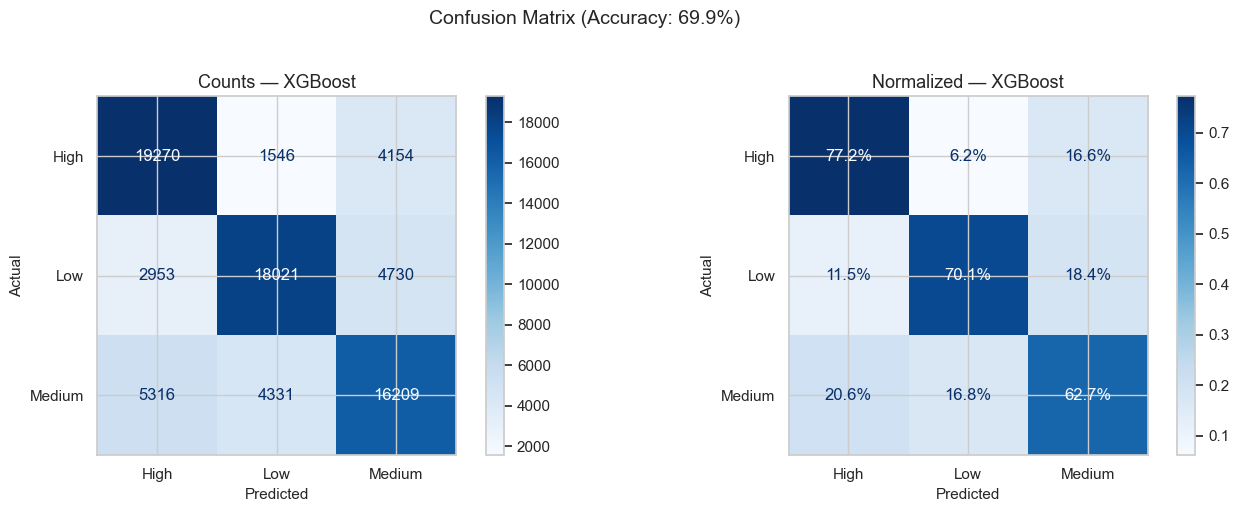

In [5]:
import os
os.makedirs('figures', exist_ok=True)

cm = confusion_matrix(y_test, best['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp1.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title(f'Counts — {best_name}', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp2.plot(cmap='Blues', values_format='.1%', ax=axes[1])
axes[1].set_title(f'Normalized — {best_name}', fontsize=13)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

fig.suptitle(f'Confusion Matrix (Accuracy: {best["accuracy"]:.1%})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/clf_1_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

**Transit Insight:** The confusion matrix reveals where the model struggles to distinguish crowding levels. Misclassifications between **Low and Medium** are expected since these are adjacent categories with overlapping PEAK_LOAD values. **High crowding misclassified as Low** would be the most dangerous error for transit planners — it means overcrowded routes going undetected.

### Visualization 2: Multi-class ROC Curves

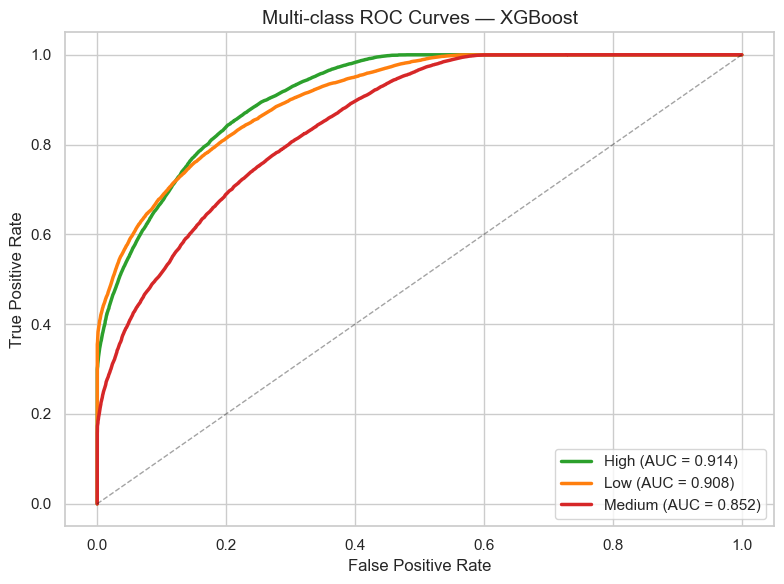

In [6]:
y_test_onehot = np.eye(len(class_names))[y_test.values]
colors = ['#2ca02c', '#ff7f0e', '#d62728']

fig, ax = plt.subplots(figsize=(8, 6))
for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], best['y_prob'][:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2.5, label=f'{cname} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'Multi-class ROC Curves — {best_name}', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('figures/clf_2_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

**Transit Insight:** AUC values close to 1.0 indicate the model reliably distinguishes each crowding level. The **High crowding AUC** is the most critical metric — a high AUC here means VTA can trust the model's overcrowding warnings. If the High AUC is lower than Low/Medium, it suggests overcrowded conditions are harder to predict and may require additional features like weather or special events.

### Visualization 3: Feature Importance (XGBoost)

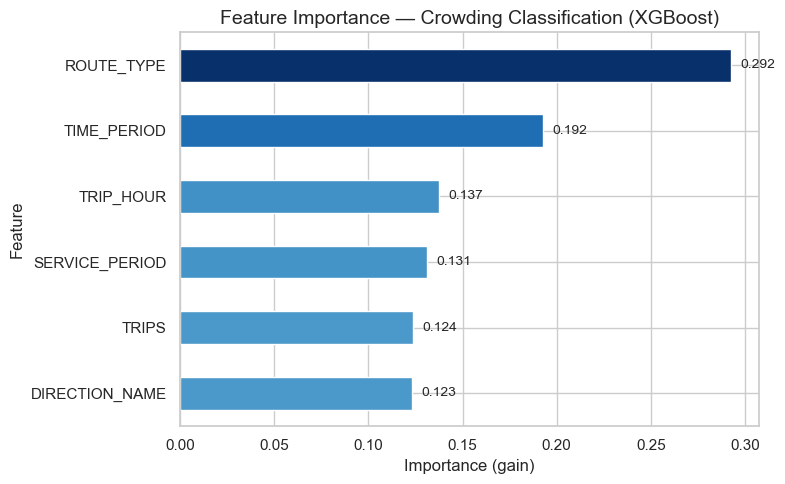

In [7]:
xgb_importance = pd.Series(
    results['XGBoost']['model'].feature_importances_,
    index=clf_features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
norm_vals = xgb_importance.values / xgb_importance.values.max()
bar_colors = plt.cm.Blues(0.3 + 0.7 * norm_vals)
xgb_importance.plot(kind='barh', color=bar_colors, ax=ax)
ax.set_xlabel('Importance (gain)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance — Crowding Classification (XGBoost)', fontsize=14)
for i, v in enumerate(xgb_importance.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('figures/clf_3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

**Transit Insight:** The most important features reveal **what drives crowding**. If `TRIPS` dominates, it means the number of scheduled trips is the strongest predictor — routes with fewer trips per day tend to be more crowded per trip. If `ROUTE_TYPE` is high, it confirms that service category (Frequent, Local, Light Rail) is a key determinant, aligning with our EDA finding that Light Rail carries the heaviest loads.

### Visualization 4: SHAP Summary Plot (Model Explainability)

Computing SHAP values (sampling 2,000 test points)...


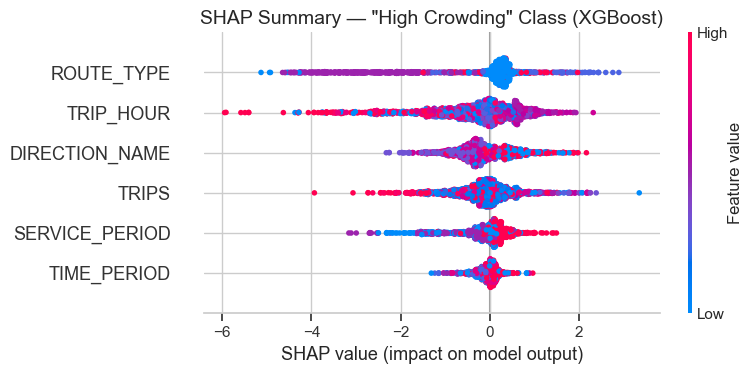

SHAP computation complete.


In [8]:
print('Computing SHAP values (sampling 2,000 test points)...')
shap_n = min(2000, len(X_test))
X_shap = X_test.sample(n=shap_n, random_state=42)

explainer = shap.TreeExplainer(results['XGBoost']['model'])
shap_values = explainer.shap_values(X_shap)

high_idx = class_names.index('High')
sv_high = shap_values[high_idx] if isinstance(shap_values, list) else shap_values[:, :, high_idx]

plt.figure(figsize=(10, 6))
shap.summary_plot(sv_high, X_shap, feature_names=clf_features, show=False)
plt.title('SHAP Summary — "High Crowding" Class (XGBoost)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/clf_4_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print('SHAP computation complete.')

**Transit Insight (Model Explainability):** SHAP values show **how each feature pushes a prediction toward or away from High crowding**. Points on the right (positive SHAP) increase the likelihood of High crowding; points on the left decrease it. The color indicates the feature value — red means high feature value, blue means low. For example, if high `TRIPS` values (red dots) cluster on the left, it means more scheduled trips actually *reduce* crowding per trip, suggesting VTA should increase trip frequency on overcrowded routes.

### Visualization 5: LDA 2D Scatter (Linear Dimensionality Reduction)

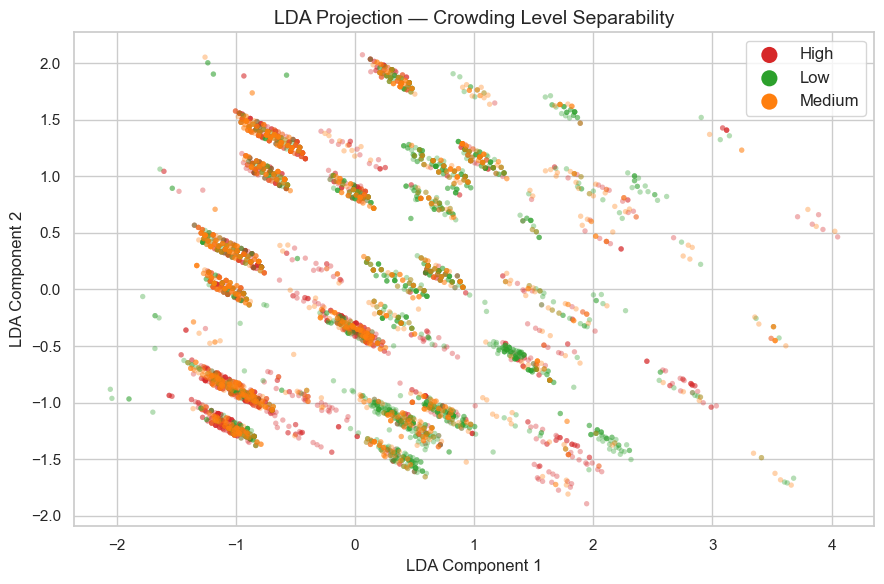

LDA explained variance ratio: [0.98434632 0.01565368]


In [9]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_train_scaled, y_train)
lda_labels = np.array([class_names[i] for i in y_train.values])

color_map = {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'}

np.random.seed(42)
sub_n = min(5000, len(X_lda))
sub_idx = np.random.choice(len(X_lda), sub_n, replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for label in class_names:
    mask = lda_labels[sub_idx] == label
    ax.scatter(X_lda[sub_idx][mask, 0], X_lda[sub_idx][mask, 1],
              c=color_map[label], label=label, alpha=0.35, s=15, edgecolors='none')

ax.set_xlabel('LDA Component 1', fontsize=12)
ax.set_ylabel('LDA Component 2', fontsize=12)
ax.set_title('LDA Projection — Crowding Level Separability', fontsize=14)
legend = ax.legend(fontsize=12, loc='upper right', markerscale=3)
for lh in legend.legend_handles:
    lh.set_alpha(1.0)
plt.tight_layout()
plt.savefig('figures/clf_5_lda_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'LDA explained variance ratio: {lda.explained_variance_ratio_}')

**Transit Insight:** LDA projects the 6 features into 2 dimensions while **maximizing class separation**. The **X markers** show each class centroid — their separation confirms the features carry discriminative information. The overlap between classes (especially Low↔Medium) explains why classification accuracy plateaus at ~70% — the crowding bins at 8.7 and 13.0 PEAK_LOAD are close together, creating an inherently fuzzy boundary that no model can perfectly resolve with these features alone.

### Visualization 6: t-SNE Scatter (Non-linear Dimensionality Reduction)

Running t-SNE on 5,000 samples...


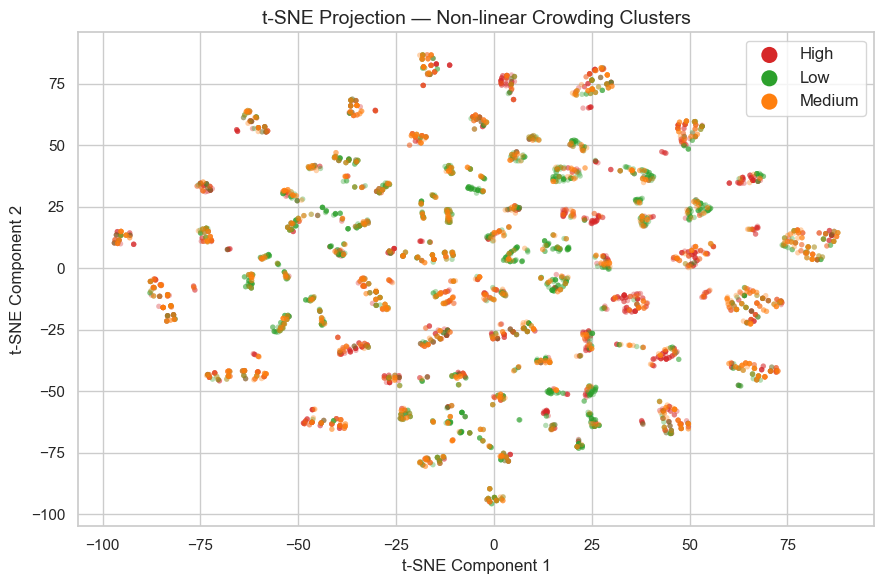

t-SNE complete.


In [10]:
tsne_n = min(5000, len(X_train))
tsne_idx = np.random.RandomState(42).choice(len(X_train), tsne_n, replace=False)
X_tsne_input = X_train_scaled[tsne_idx]
y_tsne_labels = np.array([class_names[i] for i in y_train.values[tsne_idx]])

print(f'Running t-SNE on {tsne_n:,} samples...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_input)

fig, ax = plt.subplots(figsize=(9, 6))
for label in class_names:
    mask = y_tsne_labels == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color_map[label],
              label=label, alpha=0.35, s=15, edgecolors='none')

ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.set_title('t-SNE Projection — Non-linear Crowding Clusters', fontsize=14)
legend = ax.legend(fontsize=12, loc='upper right', markerscale=3)
for lh in legend.legend_handles:
    lh.set_alpha(1.0)
plt.tight_layout()
plt.savefig('figures/clf_6_tsne_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('t-SNE complete.')

**Transit Insight:** t-SNE captures **non-linear relationships** by preserving local structure — nearby points in the original 6D feature space remain neighbors in the 2D plot. The overlap between classes is a genuine data characteristic — it reflects the continuous nature of PEAK_LOAD being split into discrete bins. This justifies using ensemble models (RF, XGBoost) which handle fuzzy boundaries better than linear classifiers.

### Visualization 7: Model Comparison

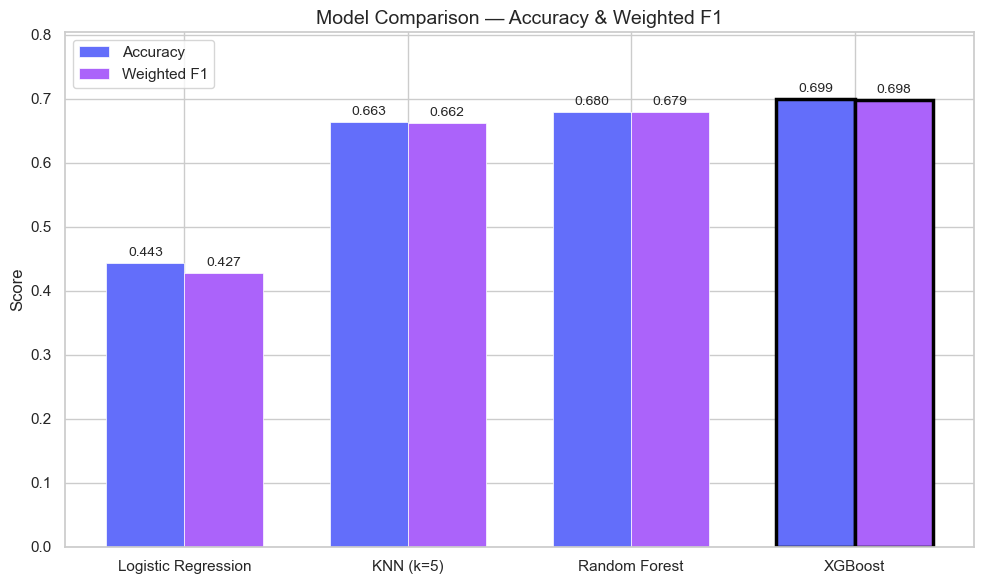

In [11]:
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
f1_scores = [results[m]['f1'] for m in model_names]

x_pos = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

edge_colors_acc = ['black' if m == best_name else 'white' for m in model_names]
edge_colors_f1 = ['black' if m == best_name else 'white' for m in model_names]
edge_widths = [2.5 if m == best_name else 0.5 for m in model_names]

bars1 = ax.bar(x_pos - width/2, accuracies, width, label='Accuracy', color='#636EFA',
               edgecolor=edge_colors_acc, linewidth=edge_widths)
bars2 = ax.bar(x_pos + width/2, f1_scores, width, label='Weighted F1', color='#AB63FA',
               edgecolor=edge_colors_f1, linewidth=edge_widths)

ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Accuracy & Weighted F1', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(accuracies), max(f1_scores)) * 1.15)
plt.tight_layout()
plt.savefig('figures/clf_7_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

**Transit Insight:** The comparison reveals how different learning paradigms perform on transit crowding prediction. **Logistic Regression** provides a linear baseline, **KNN** tests whether similar route-time combinations have similar crowding (distance-based), while **Random Forest** and **XGBoost** capture non-linear interactions through tree ensembles. If tree-based models significantly outperform KNN and Logistic Regression, it confirms that crowding depends on complex feature interactions rather than simple proximity or linear boundaries.

## Summary: Key Findings & Limitations

### Strengths
- Classification identifies which route-time combinations are likely to be overcrowded
- SHAP explainability provides actionable insights for transit planners
- LDA and t-SNE dimensionality reduction validate feature quality

### Limitations
- PEAK_LOAD binning thresholds (33rd/67th percentile) are data-dependent
- Model does not account for external factors (weather, events, construction)
- Temporal patterns may shift seasonally (October data only)

### Transit Recommendations
- Deploy the best model to flag routes predicted as "High" crowding for proactive capacity increases
- Prioritize features identified by SHAP for real-time monitoring
- Retrain quarterly as ridership patterns evolve

In [12]:
print('=' * 65)
print('CLASSIFICATION SUMMARY')
print('=' * 65)
print(f'\nTask: Predict Route Crowding Level (Low / Medium / High)')
print(f'Target: PEAK_LOAD binned at {low_thresh:.1f} / {high_thresh:.1f}')
print(f'Features: {clf_features}')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'\n{"Model":<25} {"Accuracy":>10} {"F1 (weighted)":>15}')
print('-' * 52)
for name, res in results.items():
    marker = ' <-- BEST' if name == best_name else ''
    print(f'{name:<25} {res["accuracy"]:>10.4f} {res["f1"]:>15.4f}{marker}')
print(f'\n7 ML visualizations generated.')
print(f'Total time: {ml_time:.1f}s')

CLASSIFICATION SUMMARY

Task: Predict Route Crowding Level (Low / Medium / High)
Target: PEAK_LOAD binned at 8.7 / 13.0
Features: ['ROUTE_TYPE', 'TIME_PERIOD', 'SERVICE_PERIOD', 'TRIP_HOUR', 'TRIPS', 'DIRECTION_NAME']
Train: 306,120 | Test: 76,530

Model                       Accuracy   F1 (weighted)
----------------------------------------------------
Logistic Regression           0.4428          0.4274
KNN (k=5)                     0.6635          0.6618
Random Forest                 0.6797          0.6790
XGBoost                       0.6991          0.6985 <-- BEST

7 ML visualizations generated.
Total time: 11.6s
